# Final Project: Real or Fake job Postings


In [48]:
# Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras 
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, 
                             f1_score, 
                             precision_score,
                             recall_score,
                             classification_report, 
                             confusion_matrix,  
                             precision_recall_curve)

In [49]:
# Read the dataset
df = pd.read_csv("hf://datasets/victor/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv")

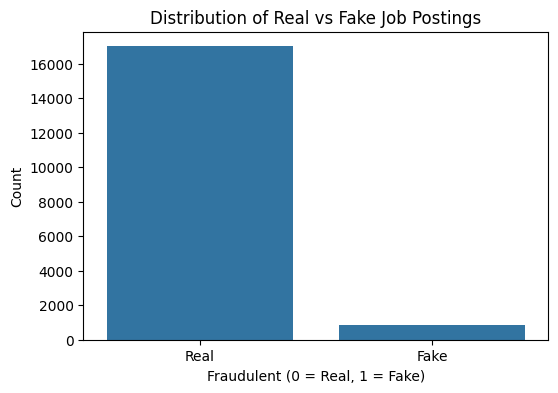

In [50]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="fraudulent")
plt.title("Distribution of Real vs Fake Job Postings")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.xticks([0,1], ["Real", "Fake"])
plt.show()

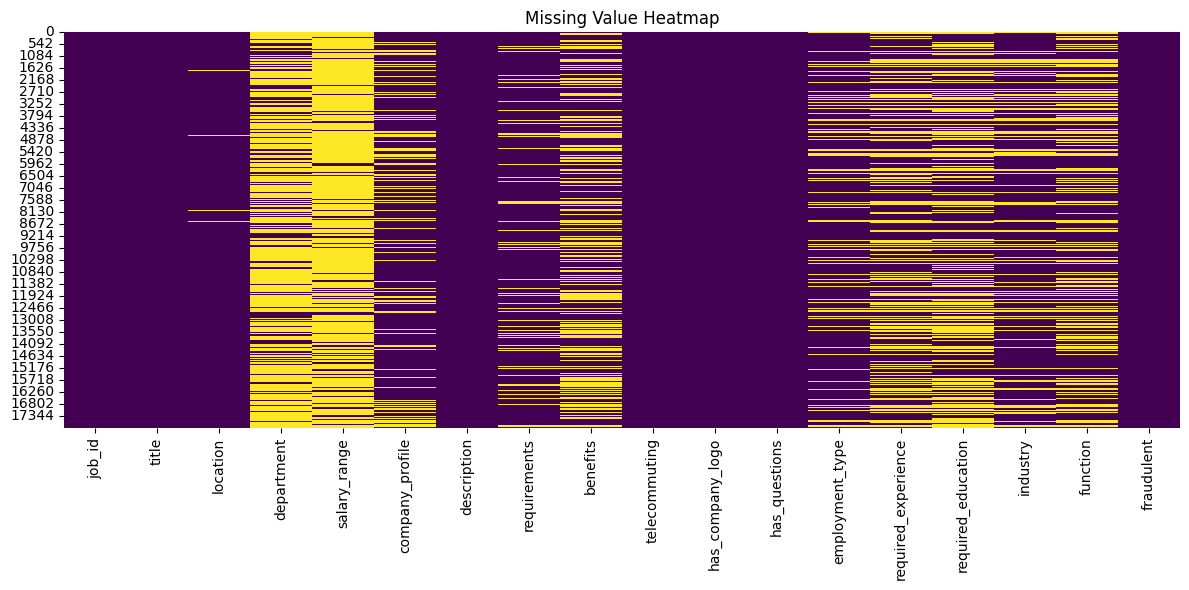

In [51]:
# Visualize missing values in the dataset
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()


In [52]:
# Data Preprocessing
text_cols = ['title', 'description', 'company_profile', 'location', 'benefits', 'requirements']
categorical_cols = ['employment_type', 'required_experience', 'required_education',
                     'industry', 'function', 'telecommuting', 'has_company_logo', 'has_questions']

# Fill missing values for text columns
for col in text_cols:
    df[col] = df[col].fillna("")

# Fill missing values for Categorical columns
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")


# Preprocessing Pipeline (Tf-idf + One-Hot Encoding)
preprocess = ColumnTransformer(
    transformers=[
        ('tfidf_title', TfidfVectorizer(max_features=5000), 'title'),
        ('tfidf_description', TfidfVectorizer(max_features=5000), 'description'),
        ('tfidf_company', TfidfVectorizer(max_features=5000), 'company_profile'),
        ('tfidf_location', TfidfVectorizer(max_features=5000), 'location'),
        ('tfidf_benefits', TfidfVectorizer(max_features=5000), 'benefits'),
        ('tfidf_requirement', TfidfVectorizer(max_features=5000), 'requirements'),
        ('ohe_employment_type', OneHotEncoder(handle_unknown='ignore'), ['employment_type']),
        ('ohe_required_experience', OneHotEncoder(handle_unknown='ignore'), ['required_experience']),
        ('ohe_required_education', OneHotEncoder(handle_unknown='ignore'), ['required_education']),
        ('ohe_industry', OneHotEncoder(handle_unknown='ignore'), ['industry']),
        ('ohe_function', OneHotEncoder(handle_unknown='ignore'), ['function']),
        ('ohe_telecommuting', OneHotEncoder(handle_unknown='ignore'), ['telecommuting']),
        ('ohe_has_company_logo', OneHotEncoder(handle_unknown='ignore'), ['has_company_logo']),
        ('ohe_has_questions', OneHotEncoder(handle_unknown='ignore'), ['has_questions'])
    ],
    remainder='drop'
)

# Split the dataset into training and validation sets
target = 'fraudulent'
features = df.columns.drop([target, 'job_id', 'salary_range', 'department'])

X_train, X_valid, y_train, y_valid= train_test_split(df[features], df[target], test_size=0.2, random_state=42, stratify=df[target])

In [53]:
# Random Forest Classifier
depths = list(range(1,25,2))
iter = [100, 200, 300]
rf_accuracies = []

# Hyperparameter tuning for Random Forest
for depth in depths:
    for num in iter:
        rf = Pipeline([
            ('preprocess', clone(preprocess)),
            ('classifier', RandomForestClassifier(
                n_estimators=num,
                max_depth=depth,
                random_state=42,
                bootstrap=True,
                class_weight='balanced',
                n_jobs=-1
            ))
        ])
        rf.fit(X_train, y_train)
        rf_accuracies.append((
            num,
            depth,
            accuracy_score(y_train, rf.predict(X_train)),
            accuracy_score(y_valid, rf.predict(X_valid))
        ))

# Find the best hyperparameters based on validation accuracy
best_depth = max(rf_accuracies, key=lambda x: x[3])[1]
best_num = max(rf_accuracies, key=lambda x: x[3])[0]
best_accuracy = max(rf_accuracies, key=lambda x: x[3])[3]

print(best_depth, best_num, best_accuracy)

23 300 0.9541387024608501


In [54]:
# Train final Random Forest model with best hyperparameters
final_rf = Pipeline([
            ('preprocess', clone(preprocess)),
            ('classifier', RandomForestClassifier(
                n_estimators=best_num, 
                max_depth=best_depth, 
                random_state=42, 
                bootstrap=True, 
                class_weight='balanced'
            ))])
final_rf.fit(X_train, y_train)

final_rf_val_pred = final_rf.predict(X_valid)
final_rf_accuracy = accuracy_score(y_valid, final_rf_val_pred)

print(f'Final Validation Accuracy: {final_rf_accuracy}')

Final Validation Accuracy: 0.9541387024608501


In [61]:
# Deep Neural Network Model
# Build DNN model
def dnn_model(shape): 
    model = keras.Sequential([
        keras.Input(shape=(shape,)),
        keras.layers.Dense(256, activation='relu'), 
        keras.layers.Dropout (0.3), 
        keras.layers.Dense(128, activation='relu'), 
        keras.layers.Dropout(0.3), 
        keras.layers.Dense(1, activation='sigmoid') ]) 
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 
    return model 

# Transform data with preprocessor
x_train_dnn = preprocess.fit_transform(X_train) 
x_valid_dnn = preprocess.transform(X_valid) 

# Train DNN model
dnn = dnn_model(x_train_dnn.shape[1]) 
dnn.fit(x_train_dnn.toarray(), y_train, epochs=5, batch_size=128) 

# Evaluate DNN model
dnn_train_loss, dnn_train_accuracy = dnn.evaluate(x_train_dnn, y_train, verbose=0) 
dnn_valid_loss, dnn_valid_accuracy = dnn.evaluate(x_valid_dnn, y_valid, verbose=0) 

# Make predictions
dnn_pred = (dnn.predict(x_valid_dnn.toarray()) > 0.5).astype(int) 

print("DNN Accuracy:", accuracy_score(y_valid, dnn_pred)) 
print([dnn_train_accuracy, dnn_valid_accuracy])

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9536 - loss: 0.1304
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9904 - loss: 0.0276
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9978 - loss: 0.0072
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9993 - loss: 0.0026
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9998 - loss: 0.0011
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DNN Accuracy: 0.9924496644295302
[1.0, 0.9924496412277222]


In [56]:
# Linear Transformer Support Vector Machine (SVM)
# Transform data with preprocessor
X_train_vec = preprocess.fit_transform(X_train)
X_valid_vec = preprocess.transform(X_valid)

svm_param = {"C": [0.01, 0.1, 1, 10, 100]}

# Train Linear SVM (BEST non-transformer classifier)
svm = LinearSVC(class_weight="balanced")

svm_grid = GridSearchCV(
    svm, 
    svm_param,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_vec, y_train)

best_svm = svm_grid.best_estimator_

# Evaluate Linear SVM
preds = best_svm.predict(X_valid_vec)

print("Best C:", svm_grid.best_params_)
print("Accuracy score:", accuracy_score(y_valid, preds))

Best C: {'C': 10}
Accuracy score: 0.9907718120805369


Text(0.5, 3.722222222222216, 'Predicted')

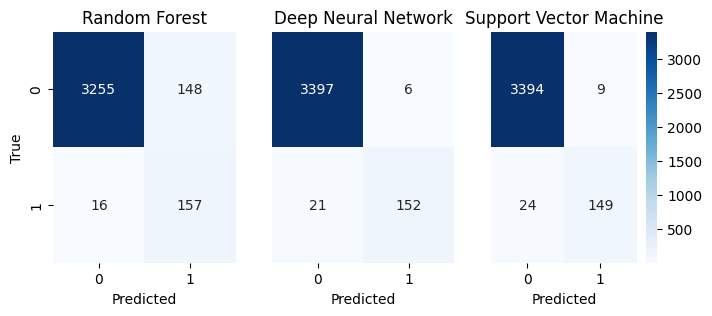

In [62]:
# Confusion Matrices
rf_matrix = confusion_matrix(y_valid, final_rf_val_pred)
dnn_matrix = confusion_matrix(y_valid, dnn_pred)
svm_matrix = confusion_matrix(y_valid, preds)

plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
sns.heatmap(rf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Random Forest')
plt.xlabel('Predicted')
plt.ylabel("True")

plt.subplot(1, 3, 2)
sns.heatmap(dnn_matrix, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Deep Neural Network')
plt.yticks([])  
plt.xlabel('Predicted')

plt.subplot(1, 3, 3)
sns.heatmap(svm_matrix, annot=True, cmap='Blues', fmt='g')
plt.title('Support Vector Machine')
plt.yticks([]) 
plt.xlabel('Predicted')

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


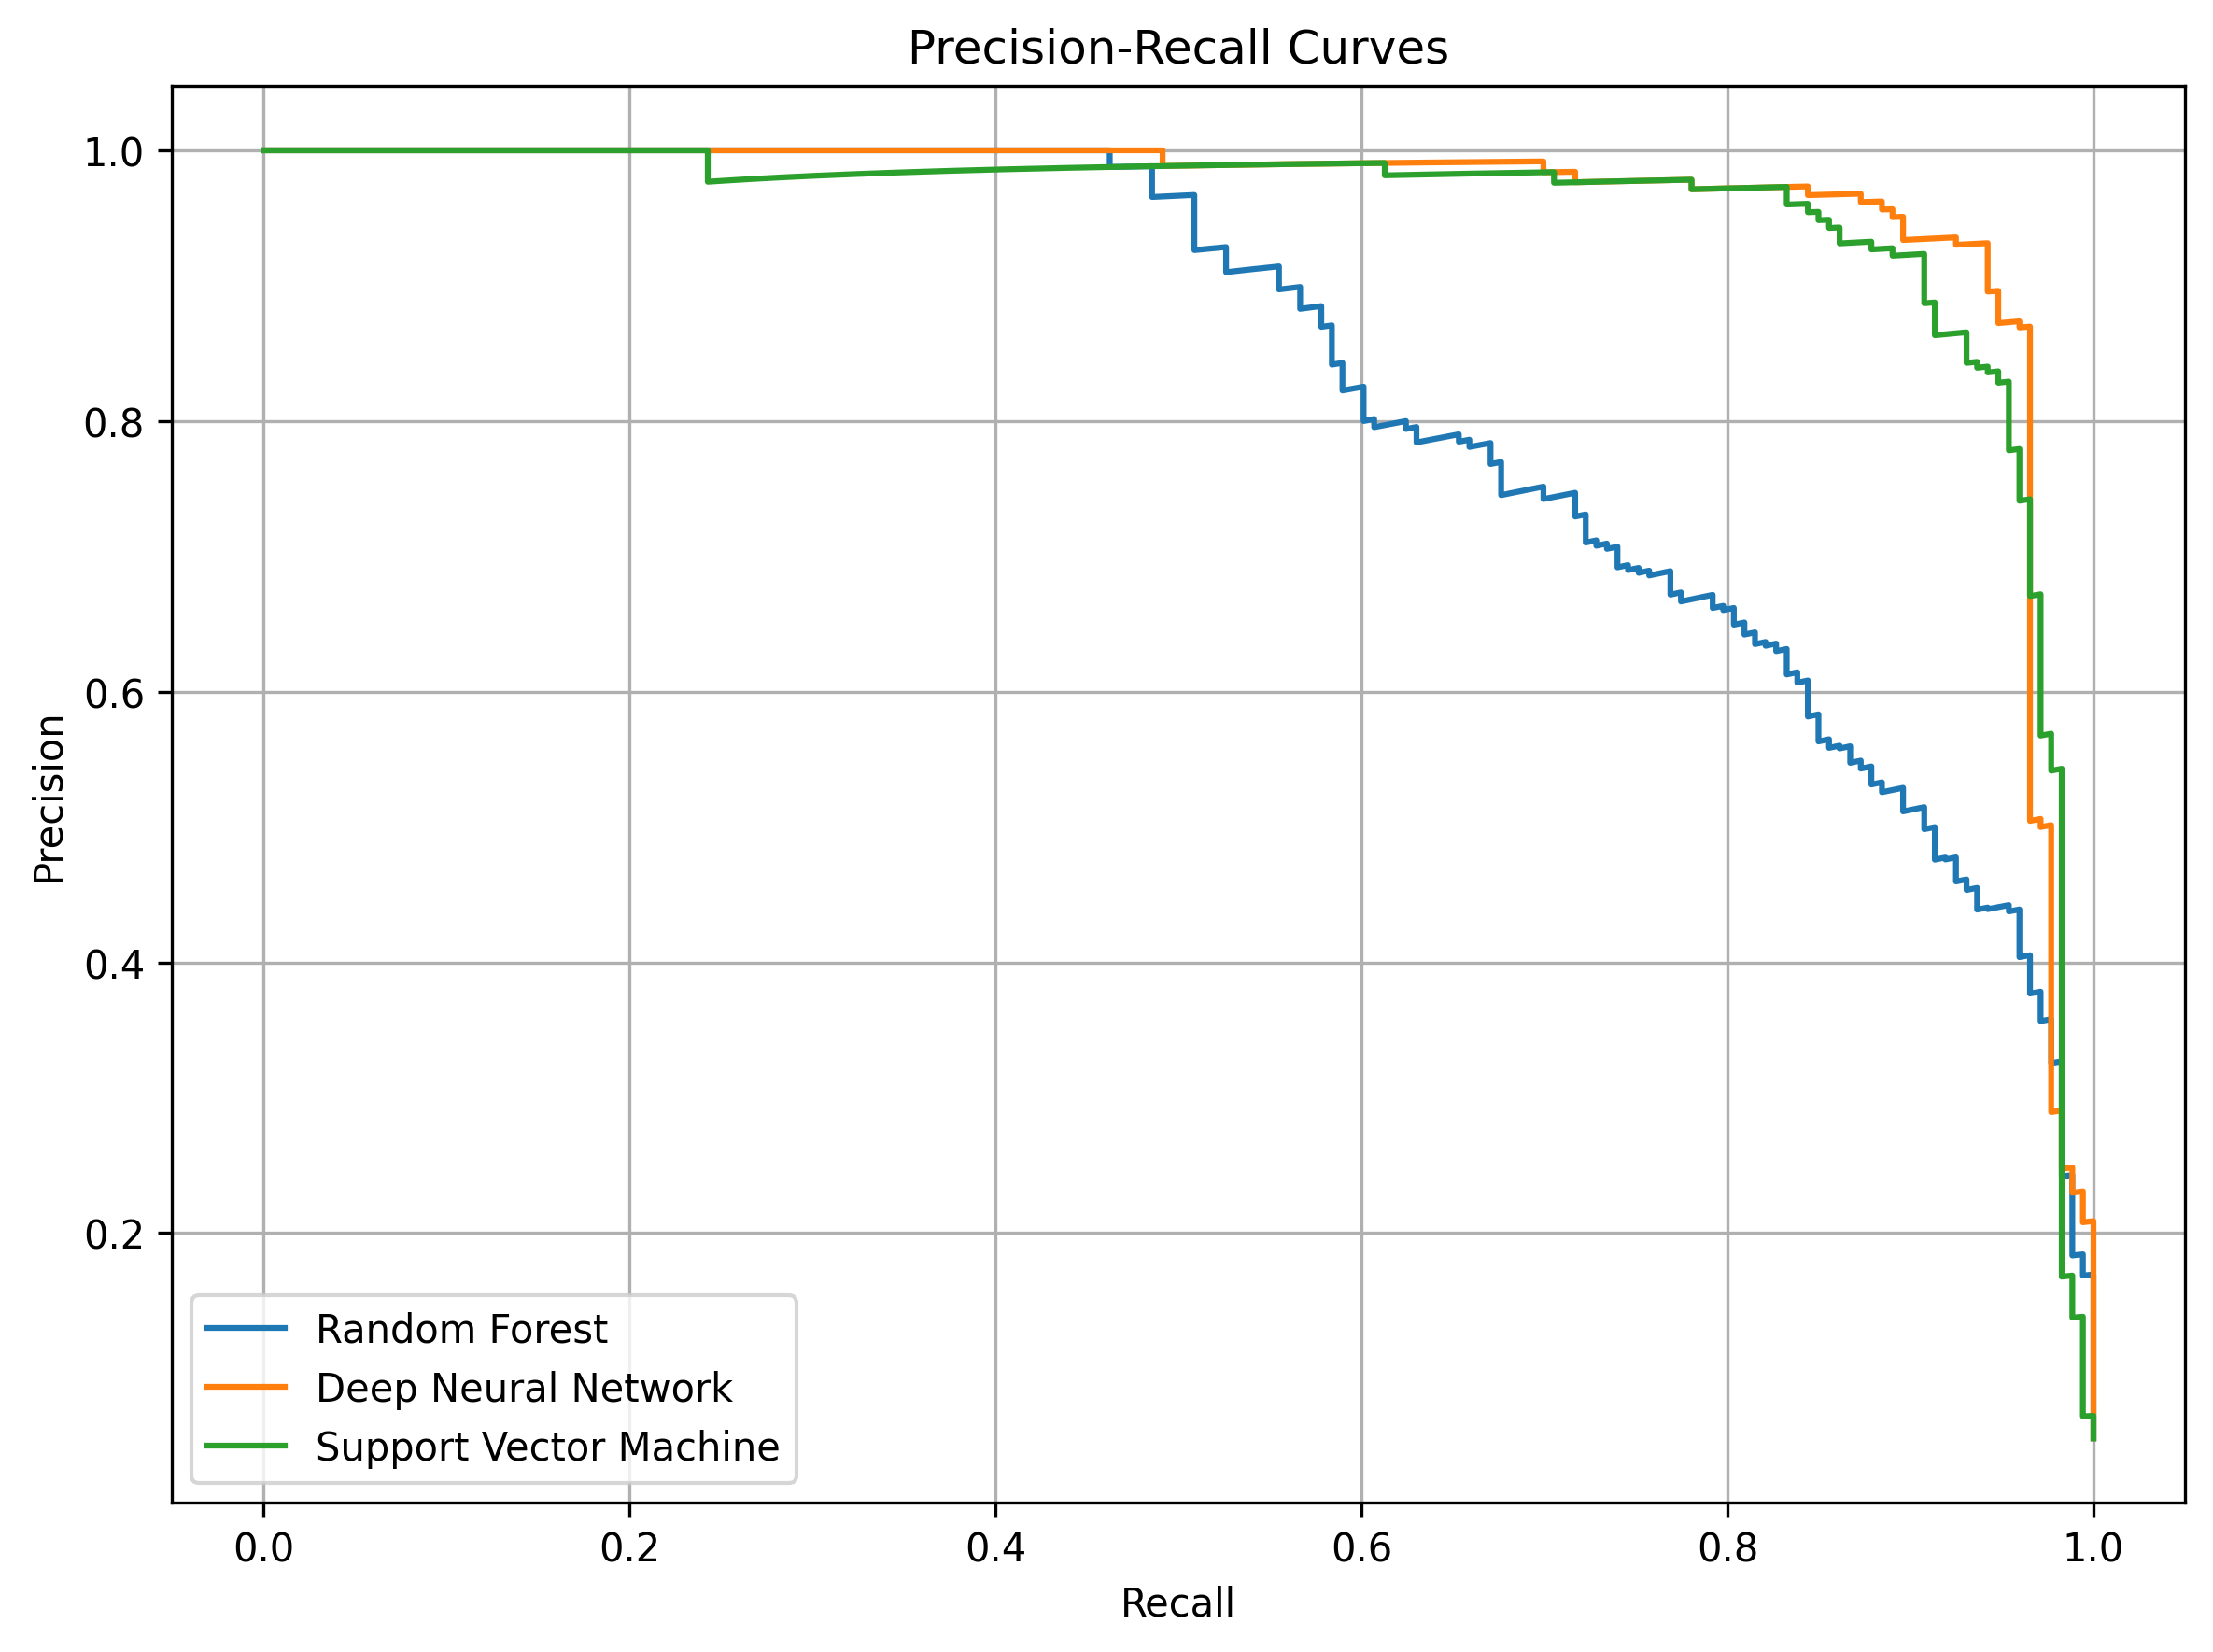

In [63]:
# Precision-Recall Curves
rf_pred_proba = final_rf.predict_proba(X_valid)[:, 1]
dnn_pred_proba = dnn.predict(x_valid_dnn.toarray()).flatten()
svm_pred_proba = best_svm.decision_function(X_valid_vec)

rf_precision_c, rf_recall_c, rf_thresholds = precision_recall_curve(y_valid, rf_pred_proba)
dnn_precision_c, dnn_recall_c, dnn_thresholds = precision_recall_curve(y_valid, dnn_pred_proba)
svm_precision_c, svm_recall_c, svm_thresholds = precision_recall_curve(y_valid, svm_pred_proba)

plt.figure(figsize=(8, 6), dpi=300)

plt.plot(rf_recall_c, rf_precision_c, label='Random Forest')
plt.plot(dnn_recall_c, dnn_precision_c, label='Deep Neural Network')
plt.plot(svm_recall_c, svm_precision_c, label='Support Vector Machine')
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() 

In [64]:
# Summary of Results
final_rf_val_pred = final_rf.predict(X_valid)
final_rf_accuracy = accuracy_score(y_valid, final_rf_val_pred)

rf_precision = precision_score(y_valid, final_rf_val_pred)
dnn_precision = precision_score(y_valid, dnn_pred)
svm_precision = precision_score(y_valid, preds)

rf_recall = recall_score(y_valid, final_rf_val_pred)
dnn_recall = recall_score(y_valid, dnn_pred)
svm_recall = recall_score(y_valid, preds)

rf_accuracy = accuracy_score(y_valid, final_rf_val_pred)
dnn_accuracy = accuracy_score(y_valid, dnn_pred)
svm_accuracy = accuracy_score(y_valid, preds)

rf_f1_score = f1_score(y_valid, final_rf_val_pred)
dnn_f1_score = f1_score(y_valid, dnn_pred)
svm_f1_score = f1_score(y_valid, preds)

results = {
    "Model": ["Random Forest", "Deep Neural Network", "Support Vector Machine"],
    "Precision": [rf_precision, dnn_precision, svm_precision],
    "Recall": [rf_recall, dnn_recall, svm_recall],
    "F1-score": [rf_f1_score, dnn_f1_score, svm_f1_score],
    "Accuracy": [rf_accuracy, dnn_accuracy, svm_accuracy]
}

data_table = pd.DataFrame(results)
data_table

,Model,Precision,Recall,F1-score,Accuracy
0,Random Forest,0.514754,0.907514,0.656904,0.954139
1,Deep Neural Network,0.962025,0.878613,0.918429,0.992450
2,Support Vector Machine,0.943038,0.861272,0.900302,0.990772
